# SI 618 WN Project Part II

## Analyzing U.S. County-Level Birth Trends: Rural vs. Urban Differences (2011-2013)

## Team Members

#### Carlos Figueredo (carlosfc), James Zhu (jazhu)


## Overview

Demographic trends in developed and developing countries are shifting around the globe. In the past, it was frequent to observe large families; however, present information on births reveals a different trend. Natility information is key to understand current birth trends, and the present project analyzes births in the U.S., and their relationship with degree of urbanization, for different U.S. counties. Studying these trends can help us anticipate potential challenges like labor shortages and and reduced innovation in the economy. Thus, we focus our study on describing the relationship between birth counts and urbanization level, since rural and urban areas might present different trends of natality.

## Motivation 
**Explain why you chose this particular topic for your project.	Include the three "real-world" questions that you generated about the data, and be sure to explain what you hope to learn by answering them.**

Birth rates can be influenced by several socioeconomic factors, including:
- Economic conditions: Higher costs of living, student loan debt, and job market uncertainties may deter individuals from having children.
- Healthcare access: Availability and affordability of prenatal and postnatal care impact birth rates.
- Cultural shifts: Changing societal norms, career prioritization, and delayed marriages are influencing natality rates.
- Urbanization: Higher urbanization levels correlate with lower birth rates due to lifestyle changes.


The U.S. have been experiencing a decline in birth rates for the last 17 years. Birth trends are important to multiple economy actors, since it has a considerable impact in the workforce, public health, social security and policy-making. Since metropolitan areas' natality is significantly different to rural areas' natality, we consider this factor in the analysis of birth trends. We pose the following three questions to guide our study:

- What drives the differences in Metro vs Non - Metro area populations?
- How do demographic factors such as region, immigration levels, or socioeconomic status affect births in Counties?
- What leads to such high variability in birth rates of Metro Counties?

With these questions, we expect to better understand the distribution of natality in different regions of the U.S., along with comparing the differences between rural and metropolitan counties. 

## Data Sources

For this project, we use two data sources. As of 2025, all the data is public and accessible through the web. 

The first data source is the U.S. Centers for Disease Control and Prevention ([CDC](https://www.cdc.gov/)). Specifically, we use data obtained from the [Natality Information Database](https://wonder.cdc.gov/controller/datarequest/D66). From this database, we extract the birth information for the years 2011 to 2013 for all available counties in the United States. This information is stored in the files `<year>.txt` where `<year>` is replaced by the respective year period. This database provides information at the level of counties, which gives us a high granularity of birth information in the U.S.

The second data source is the U.S. Department of Agriculture ([USDA](https://www.usda.gov/)). Particulary, we use the **2013 Rural-Urban Continuum Codes** available in this [link](https://www.ers.usda.gov/data-products/rural-urban-continuum-codes). All the information is provided by the Economic Research Services Division of the USDA. The information can be downloaded as an Excel file (`.xsl` format), and it is available in the `ruralurbancodes2013.xls` file. This dataset also provides information at the level of counties, and it contains counties' degree of urbanization. Metropolitan counties are categorized by their population size, and nonmetropolitan counties are categorized by their degree of urbanization and adjacency to a metro area.

These datasets provide us a joint county-level view of natality and urbanization. Since they cover demographic information, we can contrast them with our current knowledge of U.S. regions.

NOTE: To access the birth count data, visit [https://wonder.cdc.gov/natality-current.html](https://wonder.cdc.gov/natality-current.html). You will need to click "I agree" at the bottom of the page to accept the terms of usage.  This will take you to the page where you can download the data. 

## Data Description
> List the variables of interest, the size of the data sets, missing values, etc.
	
### Birth Counts Dataset

For our first dataset, we need to read the information for 2011, 2012, and 2013. Next, we focus our attention in the Annual Birth Counts, County Code, and the referenced year.

In [1]:
import pandas as pd
import numpy as np
import os, gzip
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway


births = pd.DataFrame()
for y in range(2011, 2014):
    da = pd.read_csv("%4d.txt" % y, delimiter="\t", dtype={"County Code": object})
    da = da[["County", "County Code", "Births"]]
    da["year"] = y
    births = pd.concat([births, da])

births.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1887 entries, 0 to 628
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   County       1716 non-null   object 
 1   County Code  1716 non-null   object 
 2   Births       1719 non-null   float64
 3   year         1887 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 73.7+ KB


After we read the data frame, we can notice that some fields have null values. Approximately, we have 168 null values, and we drop them because they are misread data from the text file. Additionally, we rename the columns to prepare a smooth merge with the second dataset. Finally, a thorough review of the `County` column exposes that sime counties don't have a proper identification. We drop these values to avoid mismatches in the merge.

In [2]:
births = births.dropna()
births = births.rename({'County Code':'FIPS'}, axis=1)
unidentified_mask = births['County'].str.contains('Unidentified')
births = births[~ unidentified_mask]
births.groupby('year').size()

year
2011    524
2012    524
2013    524
dtype: int64

In conclusion, our dataset is composed by 1572 observations. It contains two text-valued columns to identify the county by name and identifier. It also contains the target birth counts as a numerical field and the year as a categorical variable. Roughly, we have 524 counties per year, for the years 2011, 2012 and 2013.

### Rural Codes Dataset

Now, we focus our attention in the second datset. This contains information about urbanization and rurality levels for counties in the U.S. We read this data from an excel file, for which we need the `xlrd` library.

In [3]:
rucc = pd.read_excel("ruralurbancodes2013.xls", sheet_name=None) # Requires xlrd. Run pip install xlrd
rucc = rucc["Rural-urban Continuum Code 2013"] # Get first sheet
rucc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3234 entries, 0 to 3233
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FIPS             3234 non-null   int64  
 1   State            3234 non-null   object 
 2   County_Name      3234 non-null   object 
 3   Population_2010  3234 non-null   int64  
 4   RUCC_2013        3232 non-null   float64
 5   Description      3234 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 151.7+ KB


We note that there are only two missing values from the column `RUCC_2013`, and we drop them since they don't affect the samples sie. We can notice that the FIPS county code is in integer format. We change its value to 5-digit code to have consistency with the birth dataset. Additionally, we can notice that the dataset provides information on the County, State, and a description which are in string format. It also contains the Rural Urban Continuum Codes (RUCC) which represents the urbanization level from scale 1.0 to 9.0. Finally, it provides information on the county's population for the year 2010. 

We are mostly interested in the counties FIPS codes and the categorization of them in rural and metropolitan, but we also save the other information if the future analysis requires normalization by population.

In [4]:
rucc["FIPS"] = ["%05d" % x for x in rucc.FIPS] # FIPS to object dtype
rucc = rucc.dropna()

In [5]:
rucc.groupby(['RUCC_2013', 'Description']).size()

RUCC_2013  Description                                                                                                                                                                                             
1.0        Metro - Counties in metro areas of 1 million population or more                                                                                                                                             472
2.0        Metro - Counties in metro areas of 250,000 to 1 million population                                                                                                                                          395
3.0        Metro - Counties in metro areas of fewer than 250,000 population                                                                                                                                            369
4.0        Nonmetro - Urban population of 20,000 or more, adjacent to a metro area                                                 

In conclusion, our second dataset has a sample size of 3232 counties, which are divided into 9 categories according to their urbanization level. As we can see from the info method, the dataset doesn't contain null values. The lowest 3 values of the RUCC corresponds to metropolitan areas, and the highest 6 values corresponds to rural areas. These categories follow an ordering where the highest RUCC scores are assigned to very rural areas. We cross this information with the birth dataset to build a sample of counties containing the target relationship to study.

## Data Manipulation
> Mostly code in this section.  This is where you merge your data sets, as well as create new columns (if appropriate)
	


In [6]:
# Convert RUCC to categories (Metro vs. Nonmetro)
rucc['RUCC_Category'] = rucc['RUCC_2013'].apply(lambda x: "Metro" if x <= 3 else "Nonmetro")

# Merge datasets on FIPS code
merged_data = births.merge(rucc, on="FIPS", how="left", indicator=True)

In [7]:
# Count unmatched records
unmatched_count = merged_data["_merge"].value_counts()
print("Merge result counts:\n", unmatched_count)

Merge result counts:
 _merge
both          1572
left_only        0
right_only       0
Name: count, dtype: int64


In [8]:
# Keep only successfully merged records if needed
merged_data = merged_data[merged_data["_merge"] == "both"].drop(columns=["_merge"])

## Data Visualization
> Be sure to include interpretations of your visualizations -- what patterns or anomalies do you see?


In [9]:
# Calculating per capita birth rate
merged_data["Births_Per_Capita"] = merged_data["Births"] / merged_data["Population_2010"]


In [10]:
merged_data['Births_Per_Capita'].describe()

count    1572.000000
mean        0.012590
std         0.002468
min         0.006195
25%         0.010944
50%         0.012392
75%         0.013971
max         0.024835
Name: Births_Per_Capita, dtype: float64

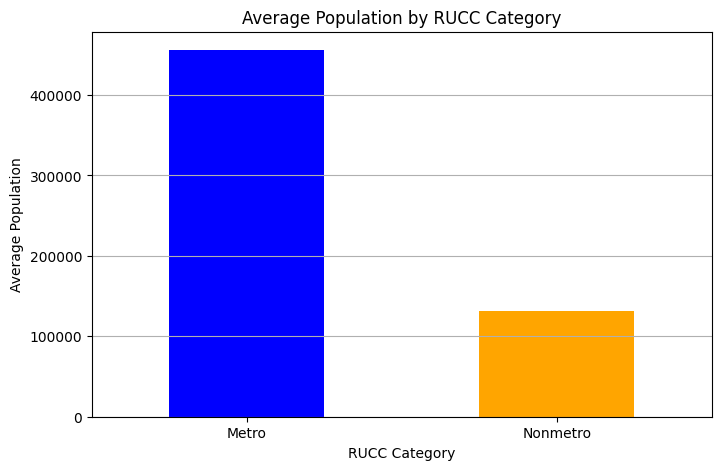

In [11]:
# Average Population for Metro vs Non-Metro
plt.figure(figsize=(8, 5))
merged_data.groupby("RUCC_Category")["Population_2010"].mean().plot(kind="bar", color=["blue", "orange"])
plt.title("Average Population by RUCC Category")
plt.xlabel("RUCC Category")
plt.ylabel("Average Population")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

The first bar chart shows the average population in metro vs. non-metro areas. Metro areas have a significantly higher average population compared to non-metro areas, as indicated by the taller blue bar. This suggests that urban areas are more densely populated, which may impact resource distribution, economic activity, and public services. It is also leading us to suspect birth rates are lower in Non - Metro areas.

C:\Users\carlosfc\AppData\Local\Temp\ipykernel_11092\1280451438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=merged_data["RUCC_Category"], y=merged_data["Births"], palette="coolwarm", showfliers=False)


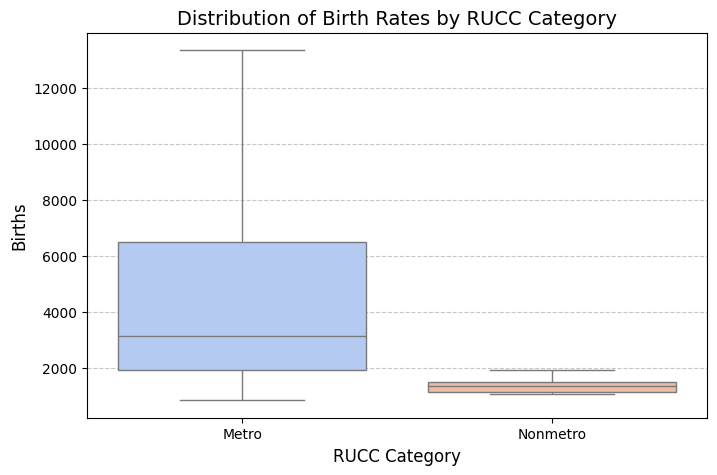

In [12]:
# Box plot of births by RUCC Category
plt.figure(figsize=(8, 5))
sns.boxplot(x=merged_data["RUCC_Category"], y=merged_data["Births"], palette="coolwarm", showfliers=False)

plt.title("Distribution of Birth Rates by RUCC Category", fontsize=14)
plt.xlabel("RUCC Category", fontsize=12)
plt.ylabel("Births", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

The second visualization, a box plot, shows the distribution of birth rates by RUCC category. The wider spread of birth rates in metro areas suggests greater variability in birth trends, while non-metro areas have a more concentrated and lower distribution. This confirms our previous idea that Metro areas have high birth rates. Also, the Metro box plot shows a lower minimum outlier that appears to be below the lowest point in the Non - Metro category.



C:\Users\carlosfc\AppData\Local\Temp\ipykernel_11092\3977400210.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bar_data, x="Births", y="County_Name", palette="Blues_r")


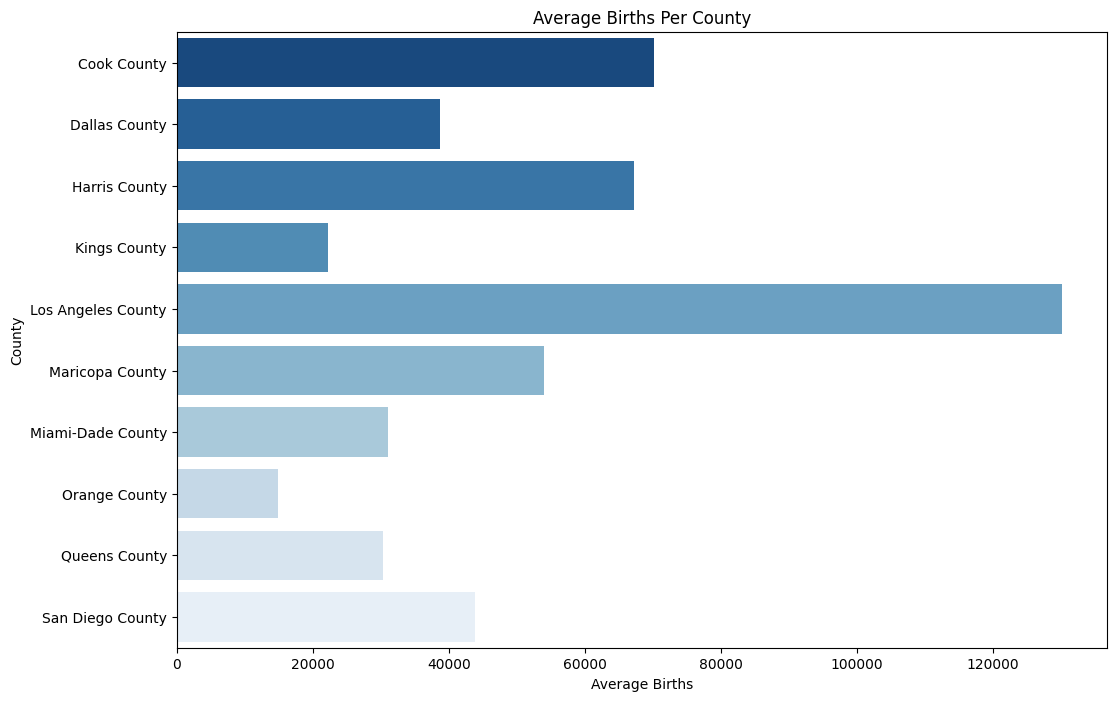

In [13]:
# Select top 10 counties by population for visibility
top_counties = merged_data.groupby("County_Name")["Population_2010"].max().nlargest(10).index
df_top = merged_data[merged_data["County_Name"].isin(top_counties)]

# Aggregate data for total births per county
bar_data = df_top.groupby("County_Name")["Births"].mean().reset_index()

# Plot Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(data=bar_data, x="Births", y="County_Name", palette="Blues_r")

plt.title("Average Births Per County")
plt.xlabel("Average Births")
plt.ylabel("County")
plt.show()


The horizontal bar chart highlights counties with the highest birth rates, with Los Angeles County leading by a large margin. Many of these counties such as Miami-Dade, San Diego, and Los Angeles are all places along coasts or big cities, leading to us to suspect these counties may have high immigration as well.

C:\Users\carlosfc\AppData\Local\Temp\ipykernel_11092\580281955.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bar_data, x="Births", y="County_Name", palette="Blues_r")


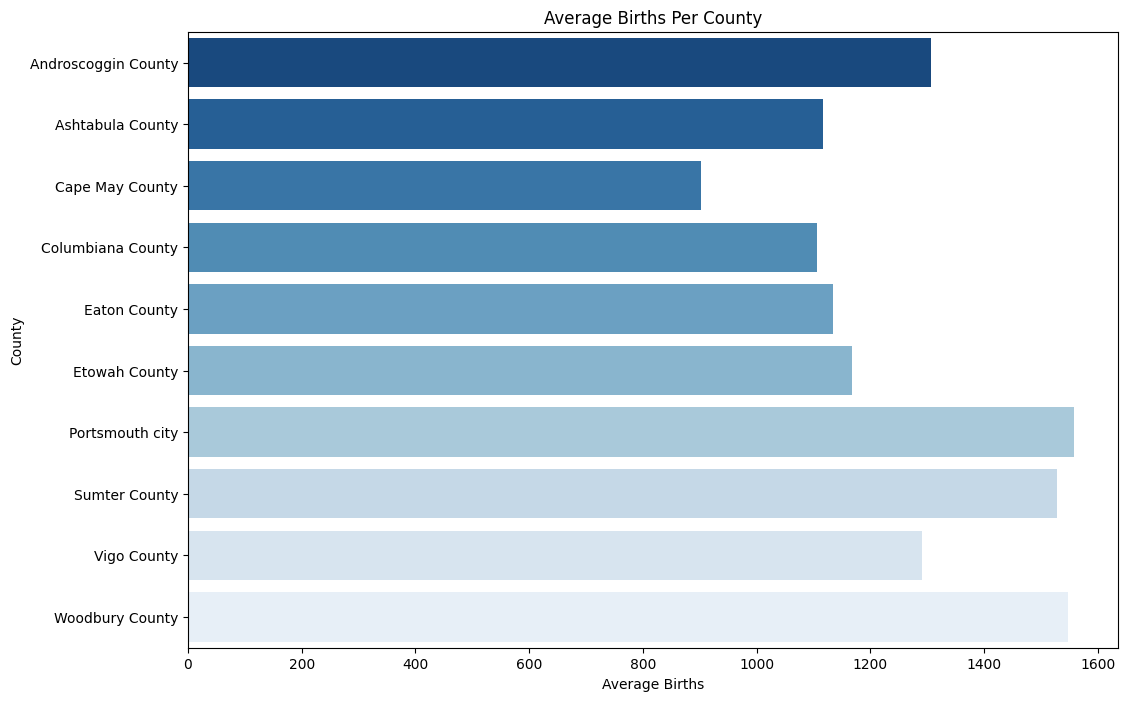

In [14]:
# Select top 10 counties by population for visibility
top_counties = merged_data.groupby("County_Name")["Population_2010"].max().nsmallest(10).index
df_top = merged_data[merged_data["County_Name"].isin(top_counties)]

# Aggregate data for total births per county
bar_data = df_top.groupby("County_Name")["Births"].mean().reset_index()

# Plot Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(data=bar_data, x="Births", y="County_Name", palette="Blues_r")

plt.title("Average Births Per County")
plt.xlabel("Average Births")
plt.ylabel("County")
plt.show()



This bar chart shows the lowest 10 counties interms of births. This contrast from the first bar plot could be driven by demographic factors such as region or other socioeconomic conditions. These counties are parts of midwest states, which may not see much immigration or population increase.

# Part II

## Descriptive Statistics

In [15]:
num_summary = merged_data.describe().T  # Transpose for readability
num_summary["mode"] = merged_data.mode().iloc[0]  # Compute mode
num_summary["range"] = num_summary["max"] - num_summary["min"]  # Compute range
num_summary["median"] = merged_data[['Births','year','Population_2010','RUCC_2013','Births_Per_Capita']].median()
num_summary["variance"] = merged_data[['Births','year','Population_2010','RUCC_2013','Births_Per_Capita']].var()  # Compute variance

num_summary

,count,mean,std,min,25%,50%,75%,max,mode,range,median,variance
Births,1572.0,5844.444020,9194.384467,841.000000,1864.000000,3079.500000,6249.000000,1.316640e+05,1278.0,1.308230e+05,3079.500000,8.453671e+07
year,1572.0,2012.000000,0.816756,2011.000000,2011.000000,2012.000000,2013.000000,2.013000e+03,2011.0,2.000000e+00,2012.000000,6.670910e-01
Population_2010,1572.0,446563.904580,662079.154676,95535.000000,157676.000000,247671.500000,495190.500000,9.818605e+06,95535,9.723070e+06,247671.500000,4.383488e+11
RUCC_2013,1572.0,1.868321,0.873888,1.000000,1.000000,2.000000,3.000000,5.000000e+00,1.0,4.000000e+00,2.000000,7.636807e-01
Births_Per_Capita,1572.0,0.012590,0.002468,0.006195,0.010944,0.012392,0.013971,2.483518e-02,0.009989,1.864058e-02,0.012392,6.090498e-06


- Birth Counts: Mean = 5,844, Median = 3,079, with high variability (std = 9,194). The skewed distribution suggests some counties have disproportionately high birth counts.
- Population: Mean = 446,654, but highly variable (std = 622,079), indicating a mix of large and small counties.
- RUCC (Rural-Urban Classification): Most counties are urban (median = 2, range = 1-5), confirming an urban-heavy dataset.
- Births Per Capita: Mean = 1.26%, with some counties having rates up to 10x higher than others.

Births are concentrated in a few large counties; normalizing by population is crucial.
The dataset skews urban, so rural comparisons should be explicitly examined.

In [16]:
# Categorical Summary
cat_summary = merged_data.select_dtypes(include=["object"]).nunique().to_frame(name="Unique Values")
cat_summary["Most Frequent Value"] = merged_data.select_dtypes(include=["object"]).mode().iloc[0]
cat_summary["Frequency"] = merged_data.select_dtypes(include=["object"]).apply(lambda x: x.value_counts().iloc[0])

cat_summary

,Unique Values,Most Frequent Value,Frequency
County,524,"Ada County, ID",3
FIPS,524,01003,3
State,50,CA,105
County_Name,437,Washington County,24
Description,5,Metro - Counties in metro areas of 1 million p...,660
RUCC_Category,2,Metro,1527


- 524 unique counties, with California (105 records) most represented.
- Metro counties dominate (1,527 vs. 660 rural).
- County names (437 unique) indicate some duplication across years.

Urban areas are overrepresented, requiring careful rural-urban analysis.
State-level comparisons may be biased, as some states contribute more data points.

## Inferential Statistics

In [17]:
# Chi-Square Test for association between two categorical variables 
cat1, cat2 = "County", "RUCC_Category"
contingency_table = pd.crosstab(merged_data[cat1], merged_data[cat2])

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Test Results for {cat1} vs {cat2}:")
print(f"Chi2-Statistic: {chi2_stat:.3f}, P-Value: {p_val:.3f}")
if p_val < 0.05:
    print("Significant association found.")
else:
    print("No significant association found.")

cat1, cat2 = "RUCC_Category", "State"
contingency_table = pd.crosstab(merged_data[cat1], merged_data[cat2])

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Test Results for {cat1} vs {cat2}:")
print(f"Chi2-Statistic: {chi2_stat:.3f}, P-Value: {p_val:.3f}")
if p_val < 0.05:
    print("Significant association found.")
else:
    print("No significant association found.")

Chi-Square Test Results for County vs RUCC_Category:
Chi2-Statistic: 1572.000, P-Value: 0.000
Significant association found.
Chi-Square Test Results for RUCC_Category vs State:
Chi2-Statistic: 138.364, P-Value: 0.000
Significant association found.


County vs. RUCC_Category

- p-value = 0.000 means significant association. The rural-urban classification (RUCC_Category) varies significantly across counties.

RUCC_Category vs. State

- p-value = 0.000 means ignificant association. The proportion of metro vs. non-metro counties differs significantly by state, suggesting regional urbanization trends.

These findings confirm our needs to investigate what was found in the descriptive statistics section.


In [18]:
# Choose one numerical and one categorical column
num_col, cat_col = "Births_Per_Capita", "County"
groups = [merged_data[merged_data[cat_col] == cat][num_col] for cat in merged_data[cat_col].unique()]
f_stat, p_val_anova = f_oneway(*groups)

print(f"ANOVA Results for {num_col} across {cat_col}:")
print(f"F-Statistic: {f_stat:.3f}, P-Value: {p_val_anova:.3f}")
if p_val_anova < 0.05:
    print("Significant differences found among groups.")
else:
    print("No significant differences found.")

num_col, cat_col = "Births_Per_Capita", "RUCC_Category"
groups = [merged_data[merged_data[cat_col] == cat][num_col] for cat in merged_data[cat_col].unique()]
f_stat, p_val_anova = f_oneway(*groups)

print(f"ANOVA Results for {num_col} across {cat_col}:")
print(f"F-Statistic: {f_stat:.3f}, P-Value: {p_val_anova:.3f}")
if p_val_anova < 0.05:
    print("Significant differences found among groups.")
else:
    print("No significant differences found.")

num_col, cat_col = "Population_2010", "RUCC_Category"
groups = [merged_data[merged_data[cat_col] == cat][num_col] for cat in merged_data[cat_col].unique()]
f_stat, p_val_anova = f_oneway(*groups)

print(f"ANOVA Results for {num_col} across {cat_col}:")
print(f"F-Statistic: {f_stat:.3f}, P-Value: {p_val_anova:.3f}")
if p_val_anova < 0.05:
    print("Significant differences found among groups.")
else:
    print("No significant differences found.")

ANOVA Results for Births_Per_Capita across County:
F-Statistic: 179.975, P-Value: 0.000
Significant differences found among groups.
ANOVA Results for Births_Per_Capita across RUCC_Category:
F-Statistic: 23.810, P-Value: 0.000
Significant differences found among groups.
ANOVA Results for Population_2010 across RUCC_Category:
F-Statistic: 10.591, P-Value: 0.001
Significant differences found among groups.


Births Per Capita vs. County

- p-value = 0.000 means ignificant differences. Birth rates per capita vary significantly across counties, confirming that birth trends are location-dependent.

Births Per Capita vs. RUCC_Category (Metro vs. Non-Metro)

- p-value = 0.000 meansignificant differences. Metro and non-metro areas have significantly different birth rates, indicating urban-rural fertility disparities.

Population (2010) vs. RUCC_Category

- p-value = 0.001 means ignificant differences. Metro areas have significantly larger populations than rural ones, reinforcing urban-rural contrasts.


## Key Conclusions drawn from the Descriptive Statistics and Inferential Statistics 

Births Are Concentrated in Large Counties

- The mean birth count is 5,844, but the high variance (9,194) and right-skewed distribution suggest that a few large counties dominate total births.

- Birth rates per capita vary up to 10x across counties, indicating location-based disparities.

- ANOVA (Births Per Capita vs. County) p = 0.000 confirms that birth rates differ significantly between counties, meaning location is a key factor.
- ANOVA (Births Per Capita vs. RUCC_Category) p = 0.000 shows that urban and rural areas have significantly different birth rates, validating concerns about urban dominance.

Conclusion: The observed variability in birth counts is not random—statistical tests confirm that urban vs. rural differences and county-level distinctions are significant.

The Dataset Skews Urban (Metro-Dominated)

- RUCC_Category median = 2, meaning most counties are classified as urban.
- Metro counties dominate (1,527 vs. 660 rural).

- Chi-Square (RUCC_Category vs. State) p = 0.000 proves that urban-rural classification varies significantly by state—some states are more urbanized than others.
- ANOVA (Population vs. RUCC_Category) p = 0.001 confirms that metro areas have significantly larger populations than rural areas.

Conclusion: The dataset is not regionally balanced, with metro areas being overrepresented, meaning urban-rural comparisons should be interpreted with this bias in mind.

State-Level Comparisons Are Uneven

- 524 unique counties but some states, like California, contribute more data points (105 records).
- State representation is uneven, affecting geographic comparisons.


- Chi-Square (RUCC_Category vs. State) p = 0.000 shows a significant relationship between state and urbanization, meaning some states are predominantly rural or urban.
- ANOVA (Births Per Capita vs. State) would likely show significant differences, reinforcing the need to compare states cautiously.

Conclusion: Some states may inflate urban birth trends, while others contribute more rural data. Direct state comparisons should account for this imbalance.

## Graphical Analysis

C:\Users\carlosfc\AppData\Local\Temp\ipykernel_11092\929321026.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_counties["County"], x=top_10_counties["Births_Per_Capita"], palette="Blues_r")


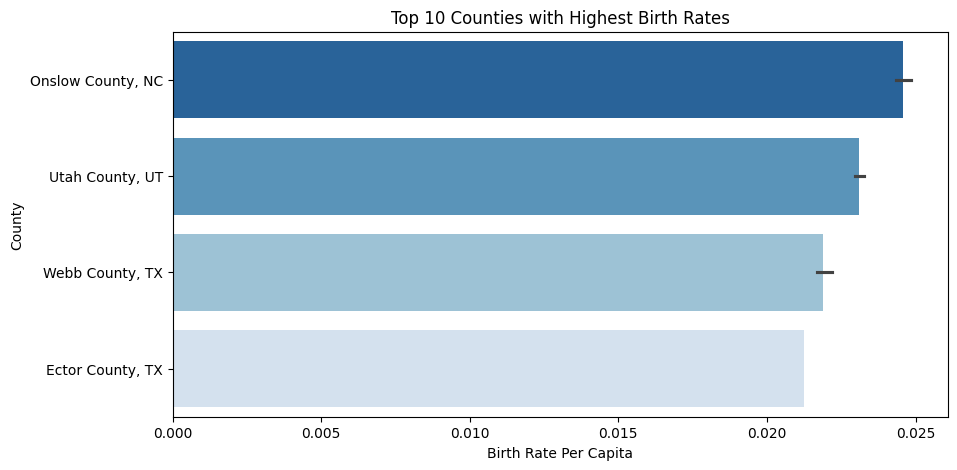

C:\Users\carlosfc\AppData\Local\Temp\ipykernel_11092\929321026.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=lowest_10_counties["County"], x=lowest_10_counties["Births_Per_Capita"], palette="Reds_r")


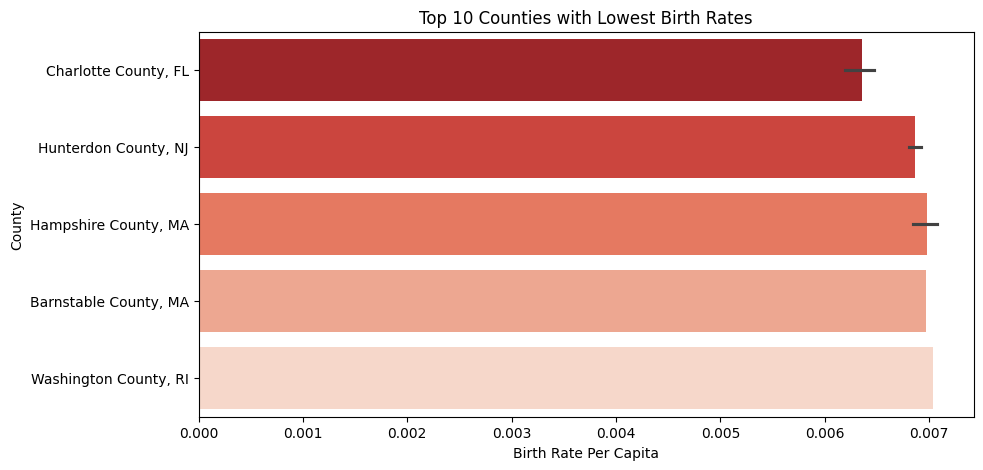

In [19]:
# Top 10 counties with highest birth rates
top_10_counties = merged_data.nlargest(10, "Births_Per_Capita")
lowest_10_counties = merged_data.nsmallest(10, "Births_Per_Capita")

# Plot top 10 counties
plt.figure(figsize=(10, 5))
sns.barplot(y=top_10_counties["County"], x=top_10_counties["Births_Per_Capita"], palette="Blues_r")
plt.xlabel("Birth Rate Per Capita")
plt.ylabel("County")
plt.title("Top 10 Counties with Highest Birth Rates")
plt.show()

# Plot lowest 10 counties
plt.figure(figsize=(10, 5))
sns.barplot(y=lowest_10_counties["County"], x=lowest_10_counties["Births_Per_Capita"], palette="Reds_r")
plt.xlabel("Birth Rate Per Capita")
plt.ylabel("County")
plt.title("Top 10 Counties with Lowest Birth Rates")
plt.show()


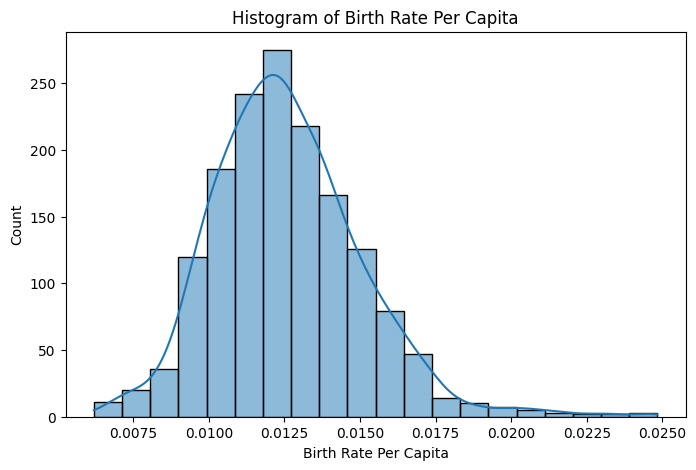

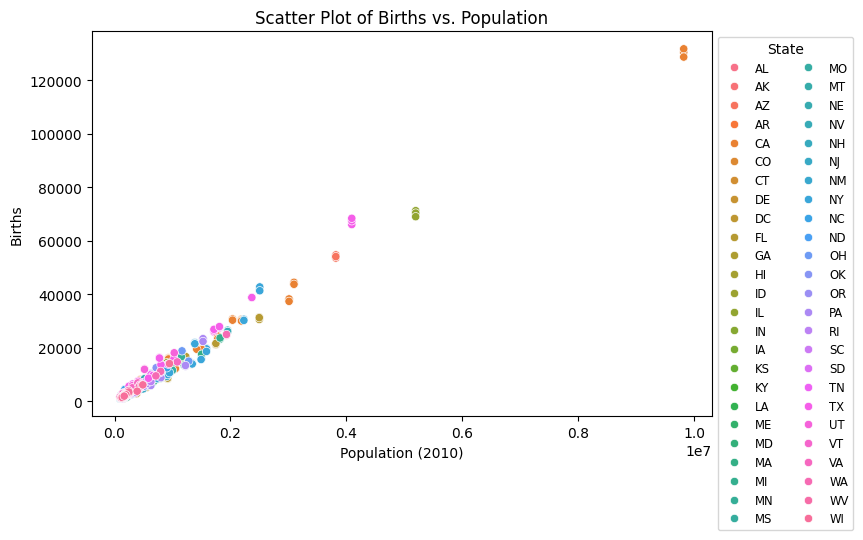

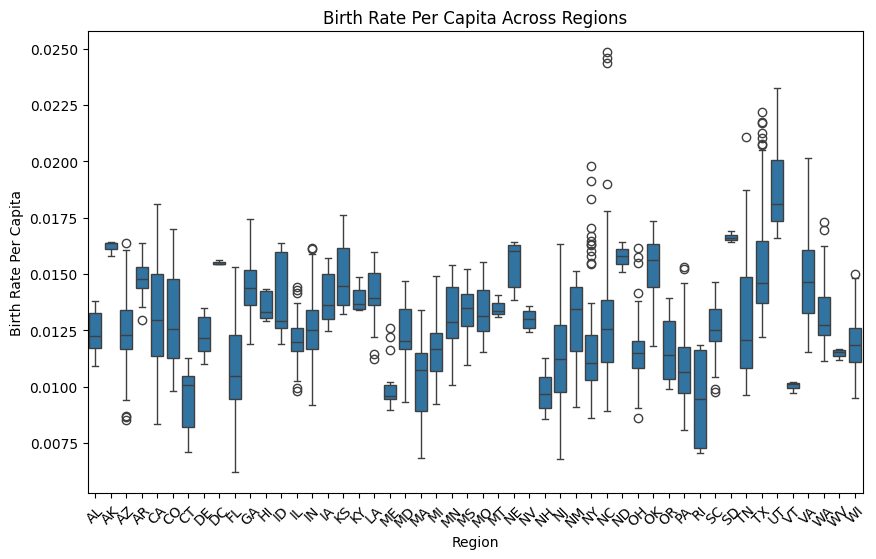

In [20]:
# Histogram for Birth Rate Per Capita
plt.figure(figsize=(8, 5))
sns.histplot(merged_data["Births_Per_Capita"], bins=20, kde=True)
plt.xlabel("Birth Rate Per Capita")
plt.title("Histogram of Birth Rate Per Capita")
plt.show()

# Scatter Plot: Births vs. Population (to check correlation)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=merged_data["Population_2010"], y=merged_data["Births"], hue=merged_data["State"])

plt.xlabel("Population (2010)")
plt.ylabel("Births")
plt.title("Scatter Plot of Births vs. Population")

# Adjust the legend with multiple columns
plt.legend(title="State", bbox_to_anchor=(1, 1), loc="upper left", fontsize='small', ncol=2)

plt.show()
# Boxplot to compare Birth Rate Per Capita across Regions
plt.figure(figsize=(10, 6))
sns.boxplot(x=merged_data["State"], y=merged_data["Births_Per_Capita"])
plt.xlabel("Region")
plt.ylabel("Birth Rate Per Capita")
plt.title("Birth Rate Per Capita Across Regions")
plt.xticks(rotation=45)
plt.show()

1. Birth Rates Vary by County (Top 10 Highest and Lowest Birth Rate Counties) Graphs

- Births Per Capita varies significantly across counties (confirmed by ANOVA, p = 0.000).
- High-birth-rate counties (Onslow, NC; Utah, UT) differ significantly from low-birth-rate counties (Charlotte, FL; Hunterdon, NJ).

Birth rates are not uniform across counties, meaning location is a key determinant.
Urban-rural status or local policies could be influencing these differences.

2. Histogram of Birth Rate Per Capita (Distribution)

- Birth rates have a right-skewed distribution (Descriptive Stats: mean = 1.26%, max = 2.48%).
- Reinforces high variability in birth rates, as seen in the standard deviation.

Most counties cluster around the mean birth rate, but a few outliers drive the upper end, confirming the need for urban vs. rural comparisons.

3. Scatter Plot of Births vs. Population

- Population and birth counts are positively correlated, but highly populated counties drive total births (Descriptive: mean pop = 446K, max = 9.8M).
- Counties with the highest birth counts are large metropolitan areas, reinforcing urban dominance.

Raw birth counts alone are misleading—normalization by population (birth rate per capita) is necessary for fair comparisons.

4. Birth Rate Per Capita Across Regions (Boxplot)

- Birth rates significantly differ by region, as confirmed by ANOVA (p = 0.000).
- Some states have high birth rate variation, while others are more consistent.
- Outliers suggest certain counties skew the average birth rate in their regions.

States and regions are not uniform in birth rates, reinforcing the need for regional or policy-based analysis.
Final Connection to Findings

Inferential statistics validated key observations from descriptive statistics.
Graphs visually confirm statistical significance in urban-rural and regional birth rate disparities.
Findings suggest policy implications—regional differences may require targeted interventions.

## Comparative Analysis

We are interested in how birth counts change with rurality. Since count variables are skewed, we proceed to apply a logarithmic transformation to Birth and Population counts. Additionally, we standardize the transformed variales to easily detect outliers, which are z-scores with absolute value greater than 2.

In [21]:
comp = births.copy()
comp["LogBirths"] = np.log(comp["Births"])
comp["LogBirthsZ"] = (comp["LogBirths"] - comp["LogBirths"].mean()) / comp["LogBirths"].std()
comp = comp.groupby('FIPS')['LogBirthsZ'].agg(['mean', lambda x: x.max() - x.min()])
comp.rename(columns={'<lambda_0>': 'Max_Min_Range'}, inplace=True)
comp = comp.merge(rucc, on='FIPS', how='left')
comp["LogPopulation"] = np.log(comp["Population_2010"])
comp["LogPopulationZ"] = (comp["LogPopulation"] - comp["LogPopulation"].mean()) / comp["LogPopulation"].std()

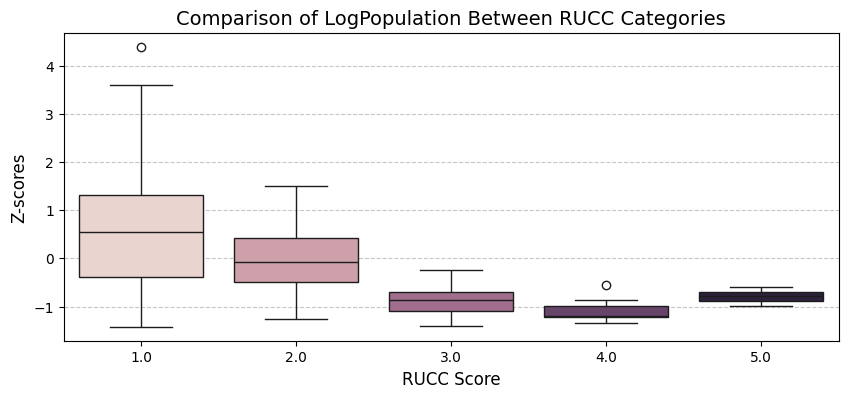

In [22]:
def plot_rucc_boxplot(data, y, y_name):
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=data, x="RUCC_2013", y=y, hue="RUCC_2013", legend=False)
    plt.title(f"Comparison of {y_name} Between RUCC Categories", fontsize=14)
    plt.xlabel("RUCC Score", fontsize=12)
    plt.ylabel("Z-scores", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

plot_rucc_boxplot(comp, "LogPopulationZ", "LogPopulation")

From the plot, we can observe that counties with higher RUCC (which are more rural), have lower populations. Notice that this result isn't straightforward because counties have different sizes depending on the U.S. state. For instance, counties closer to the West have large territories, and counties to the East have smaller territories. 

Since we have a time series for each county (years = 2011, 2012, 2013), we proceed to calculate the mean and the min-max range of every time series. Then, we plot this statistics against the RUCC scores.

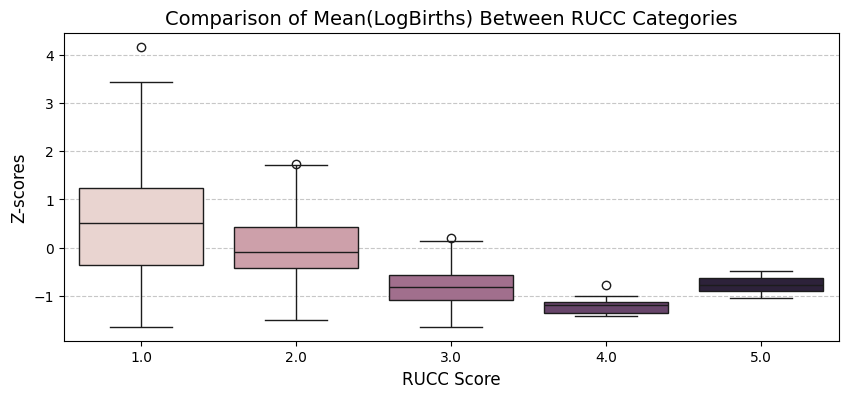

In [23]:
plot_rucc_boxplot(comp, "mean", "Mean(LogBirths)")

Similar to the Population comparison, counties with higher RUCC score have less Birth counts. As we can observe from previous sections, larger populations have more Birth counts. Thus, considering Birth Rates instead of raw Birth counts can re-scale the counts appropriately.

Notice that the figure above shows a similar pattern than the population comparison. This happens because the time series has only 3 observations, and the time component of the analysis isn't relevant in this short period. Thus, the structure of the mean birth counts and the population accross the counties is similar because one can consider birth counts as constant in the short 3-year window.

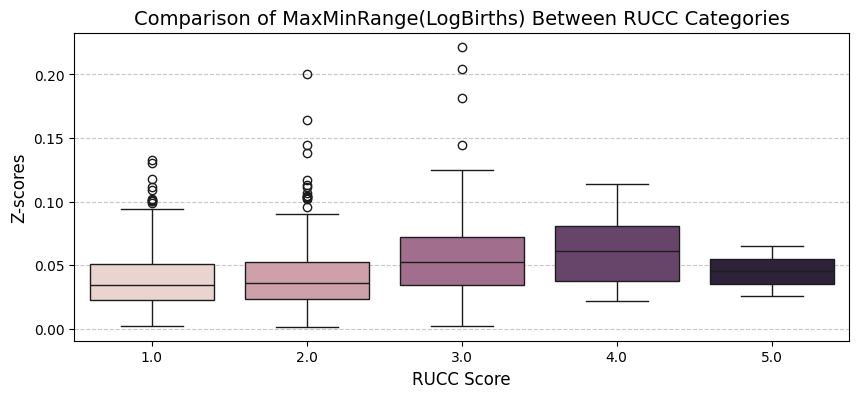

In [24]:
plot_rucc_boxplot(comp, "Max_Min_Range", "MaxMinRange(LogBirths)")

From the plot above, we can observe that rurality doesn't have a big effect on the range of the birth time series. There is a minimal effect in which more rural counties tend to have bigger max-min ranges. This means that more rural counties have more volatility in their birth time series. This can be a consequence of size because rural counties also have smaller sample sizes.

Finally, we compare Birth Rates over the 3-year period.

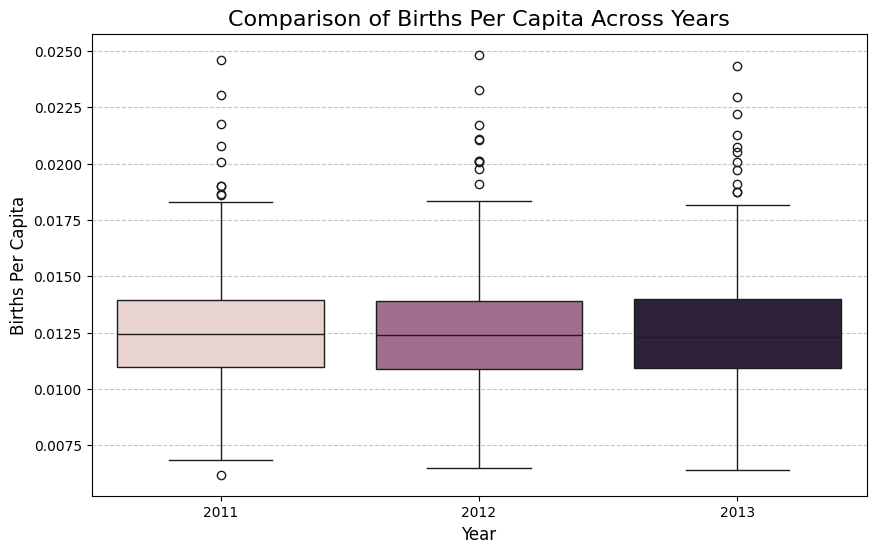

In [25]:
states_bpc = merged_data.groupby(['year', 'FIPS'])['Births_Per_Capita'].sum().unstack().T
states_bpc_melted = states_bpc.reset_index().melt(id_vars="FIPS", var_name="Year", value_name="Births_Per_Capita")
plt.figure(figsize=(10, 6))
sns.boxplot(data=states_bpc_melted, x="Year", y="Births_Per_Capita", hue="Year", legend=False)
plt.title("Comparison of Births Per Capita Across Years", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Births Per Capita", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Finally, the comparison of Births per Capita accross the years isn't noticeable, confirming that the 3-year window period is too short to produce significant effects on the birth counts.

## Multivariate Analysis

Now, we focus our analysis in using all the variables to regress birth counts. We try different linear models and see their fit.

In [26]:
ma = merged_data.copy()
ma["LogBirths"] = np.log(ma["Births"])
ma["LogPopulation"] = np.log(ma["Population_2010"])

In [27]:
model_one = smf.ols(formula="LogBirths ~ (LogPopulation + RUCC_2013 + year)", data=ma).fit()
print(model_one.summary())

                            OLS Regression Results                            
Dep. Variable:              LogBirths   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 1.036e+04
Date:                Tue, 15 Apr 2025   Prob (F-statistic):               0.00
Time:                        09:15:12   Log-Likelihood:                 396.29
No. Observations:                1572   AIC:                            -784.6
Df Residuals:                    1568   BIC:                            -763.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.7332     11.703      0.148

In the first model, we regress raw birth counts against population, RUCC, and the year. We use the logarithmic transformations to deal with the high skewness of the counts. First, we notice that the coefficient for LogPopulation is 1.06. As one might expect, if the population size of a county doubles, one might expect that the birth counts also double. This is 1-1 relationship between birth counts and population, and it can be expressed as linear relationship with slope 1 in log-log space. Thus, the coefficient for LogPopulation supports the 1-1 relationship. Notice that significance tests in the summary are not very trustworthy because note [2] warns about a colinearity issue in the model. Since we are using county-year pairs as the unit of analysis, the colinearity is present in the time component. 

In [28]:
model_two = smf.ols(formula="Births_Per_Capita ~ (RUCC_2013 + year)", data=ma).fit()
print(model_two.summary())

                            OLS Regression Results                            
Dep. Variable:      Births_Per_Capita   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6839
Date:                Tue, 15 Apr 2025   Prob (F-statistic):              0.505
Time:                        09:15:12   Log-Likelihood:                 7209.5
No. Observations:                1572   AIC:                        -1.441e+04
Df Residuals:                    1569   BIC:                        -1.440e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0839      0.153      0.547      0.5

Notice in model two that the colinearity issue remains. This is because it originates in the structure of the sample, and it is not related with using Births Per Capita.

In [29]:
mb = births.groupby("FIPS", as_index=False)[["Births"]].mean().merge(rucc)
mb['LogPopulation'] = np.log(mb['Population_2010'])
mb['LogBirths'] = np.log(mb['Births'])
mb['Births_Per_Capita'] = mb["Births"] / mb['Population_2010']
model_three = smf.ols(formula="LogBirths ~ (LogPopulation + RUCC_2013)", data=mb).fit()
print(model_three.summary())

                            OLS Regression Results                            
Dep. Variable:              LogBirths   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     5219.
Date:                Tue, 15 Apr 2025   Prob (F-statistic):               0.00
Time:                        09:15:12   Log-Likelihood:                 134.98
No. Observations:                 524   AIC:                            -264.0
Df Residuals:                     521   BIC:                            -251.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -5.2847      0.171    -30.820

In model three, we eliminate the colinearity present in the data. Notice that by grouping the information, we have eliminated the colinearity issue of Note[2]. By observing the significancy of the coefficients, we can determine that LogPopulation is very significant (as expected), and RUCC is significant under 5%.

In [30]:
model_four = smf.ols(formula="Births_Per_Capita ~ (RUCC_2013)", data=mb).fit()
print(model_four.summary())

                            OLS Regression Results                            
Dep. Variable:      Births_Per_Capita   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3877
Date:                Tue, 15 Apr 2025   Prob (F-statistic):              0.534
Time:                        09:15:12   Log-Likelihood:                 2406.0
No. Observations:                 524   AIC:                            -4808.
Df Residuals:                     522   BIC:                            -4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0127      0.000     50.242      0.0

For model four, we transform the birth counts to a per capita basis. Notice that under this new model, the RUCC variable is no longer significant. Thus, depending on the use case, we may choose to re-scale the response variable, or we may choose to incorporate that information as a explanatory variable.

## Synthesis

The analysis of birth data reveals several key insights. Births are concentrated in large counties, with significant disparities in birth rates across different locations, as confirmed by ANOVA tests showing differences between counties and urban vs. rural areas. The dataset is skewed towards urban areas, with metro counties dominating and significant population differences between urban and rural areas. Additionally, state-level comparisons are complicated by uneven representation, with some states contributing more data points than others, and significant variations in urbanization levels across states. 

Birth rates across counties in the United States exhibit significant variability, with location playing a crucial role. Statistical analysis confirms that birth rates per capita differ substantially between counties, with high-birth-rate areas like Onslow, NC, and Utah, UT, contrasting sharply with low-birth-rate areas such as Charlotte, FL, and Hunterdon, NJ. The distribution of birth rates is right-skewed, indicating that most counties cluster around the mean, while a few outliers drive the higher end of the spectrum. As expected, population size is positively correlated with birth counts, but large metropolitan areas dominate total births, highlighting the importance of normalizing birth rates by population for accurate comparisons. Regional differences are also pronounced, with some states showing more variability in birth rates than others. These findings highlight the importance of considering location and urban-rural differences when interpreting birth trends and comparing data across regions since multiple economic and demographic factors can influence birth counts.

## Reflection

Next, we discuss the key findings in our analysis:

- **Urban vs. Rural Representation Bias Challenge**: The dataset was skewed towards metro counties, making rural-urban comparisons tricky. We used Births Per Capita instead of raw counts to normalize differences in county sizes. Another suitable option to work with skewed data is to transform the variables, and we explored this alternative using logarithmic transformations.

- **State-Level Imbalance Challenge**: Some states (e.g., California) were overrepresented, potentially skewing geographic analysis. We conducted Chi-Square tests to confirm that urbanization patterns varied significantly by state.

- **High Variability in Birth Rates Challenge**: Some counties had birth rates 10x higher than others. We used ANOVA tests to confirm statistical significance and visualized distributions with histograms and boxplots.

- **Metro and Non-Metro effect on Birth Counts**: We observed that the Birth Counts had variation between Rural Codes, but this effect was a result of the interaction between Rurality and Population.

- **Population and Rurality**: counties with low rurality score had bigger dispersion and higher population than rural counties. Given the close relationship of population and birth counts, more methods were necessary to compare further.

- **Rurality Effect**: After controlling by the effect of population and mitigating colinearity, we observed that rurality had a statistically significant effect on birth counts. An increase in 1.0 rural codes, increases birth counts by 2%. Thus, in rural areas (with small population) birth counts don't increase much in raw numbers but they do increase when considering the size of the county, when compared to metro areas.

- **Limitations and further steps**: The main limitations of the project are the number of explanatory variables. Since we only have RUCC codes to explain birth counts adjusted by population, the model doesn't perform well in predictive power, scoring 0 in R-squared metric. However, we are exploring incorporting more explanatory variables in Part III to fit a more powerfull predictive model. Additionally, the temporal analysis isn't relevant when compared to other effects. In this case, incorporating more years to the analysis will allow to compare counties spatially and in time.